In [1]:
# Borreguero Monleon Héctor
# Fernández Muñoz Andrés
# Gómez García Javier

In [2]:
from pyspark import SparkContext
import findspark
findspark.init()
import math

import numpy as np
import warnings
warnings.filterwarnings("ignore")

sc = SparkContext(master="local[*]", appName="TextFileExample")

DATA_FILE = "botnet_tot_syn_l.csv"
X_SIZE = 11
Y_SIZE = 1
N_ITER = 10
LEARNING_RATE = 1.5


25/10/26 23:04:14 WARN Utils: Your hostname, fernandez-pc resolves to a loopback address: 127.0.1.1; using 192.168.0.20 instead (on interface wlp2s0)
25/10/26 23:04:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/26 23:04:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
def readFile(filename):
    rdd = sc.textFile(filename)
    def map_line(line):
        elements = [float(element) for element in line.split(",")]
        return (np.array(elements[:-1]), int(elements[-1]))
    return rdd.map(map_line)


def normalize (RDD_Xy):
    rdd_col = RDD_Xy.map(lambda xy: (np.array(xy[:-1], dtype=float).flatten(), int(xy[-1])))
    sum_vec = rdd_col.map(lambda xy: xy[0]).reduce(lambda a, b: a + b)
    media = sum_vec / RDD_Xy.count()
    varianza = rdd_col.map(lambda v: (v[0]-media)**2).reduce(lambda a,b:a+b)/ RDD_Xy.count()
    std = np.sqrt(varianza)
    return rdd_col.map(lambda v: ((v[0] - media)/std, v[1]))


def train(RDD_Xy, iterations, learning_rate):
    
    sigma = lambda z : (1 / (1 + (np.e**(-z))))
    
    np.random.seed(20)
    W = np.random.uniform(-1, 1, X_SIZE)
    b = 0
    
    def calculate_dw(rdd, W, b):
        rdd = rdd.map(lambda xy: np.array([(sigma(np.dot(W, xy[0]) + b) - xy[1]) * x_i for x_i in xy[0]]))
        dw = rdd.reduce(lambda a, b : a + b) / rdd.count()
        return dw
    
    def calculate_db(rdd, W, b):
        rdd = rdd.map(lambda xy: sigma(np.dot(W, xy[0]) + b) - xy[1])
        db = rdd.reduce(lambda a, b : a + b) / rdd.count()
        return db
    
    def get_cost_fnc(rdd, W, b):
        sigma = lambda z : (1 / (1 + (np.e**(-z))))
        rdd_costs = rdd.map(lambda xy: (lambda X, y: -y*math.log(sigma(np.dot(W, X) + b)) - (1 - y)*math.log(1 - sigma(np.dot(W, X) + b)))(*xy))
        total_cost = rdd_costs.reduce(lambda a, b: a + b)
        return total_cost / rdd.count()
    
    costs = []
    for _ in range(iterations):
        dw = calculate_dw(RDD_Xy, W, b)
        db = calculate_db(RDD_Xy, W, b)
        W = W - learning_rate * dw
        b = b - learning_rate * db
        costs.append(get_cost_fnc(RDD_Xy, W, b))
    
    return W, b, costs

def accuracy(w, b, RDD_Xy):
    predictions = RDD_Xy.map(lambda v: [predict(w, b, v[0]),v[1]])
    correct_count = predictions.map(lambda v: 1 if v[0]==v[1] else 0)
    count = correct_count.reduce(lambda a, b : a + b)
    return count / RDD_Xy.count()

def predict(w, b, data):
    sigma = lambda z : (1 / (1 + (np.e**(-z))))
    res = sigma((w*data[0]).sum() + b)
    if(res>=0.5): 
        return 1
    else:
        return 0

Accuracy:  0.572027


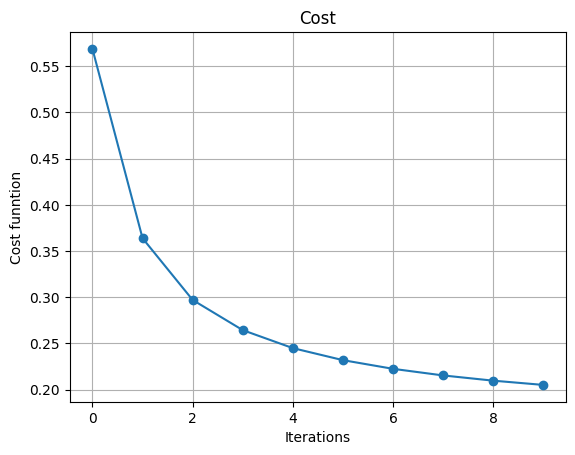

In [4]:
# read data
data = readFile(DATA_FILE)
n = data.count()

rdd_norm=normalize(data)
W, b, costs = train(rdd_norm, N_ITER, LEARNING_RATE)

acc = accuracy(W, b, rdd_norm)
print("Accuracy: ", acc)


import matplotlib.pyplot as plt
plt.plot(range(N_ITER), costs, '-o')
plt.xlabel('Iterations')
plt.ylabel('Cost funntion')
plt.title('Cost')
plt.grid()
plt.show()
# Se aprecia la disminución de la función de coste al inicio, pero finalmente converge indicando que el modelo no puede aprender más.